# Comparing influence functions with the IOM for deep learning

The goal of this notebook is to compare the influence function in deep learning with the IOM. The for the influence functions is taken from the `pyDVL` package.

In [0]:
pip install distributed zarr

Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
import pandas as pd
import numpy as np
import logging

import torch
from torch import nn
import torch.nn.functional as F
from torch.optim import Adam, Optimizer
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import lr_scheduler
from tqdm.notebook import tqdm

from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.datasets import load_breast_cancer
from typing import Callable, List, Optional, Tuple, NamedTuple
from numpy.typing import NDArray

from pingouin import multivariate_normality
from scipy import stats

import seaborn as sns
import matplotlib.pyplot as plt

import shap

from pydvl.influence.torch import DirectInfluence
import normflows as nf

In [0]:
%run /Workspace/Users/jonc@bocdaz.ca/main_iom

In [0]:
logger = logging.getLogger(__name__)

In [0]:
def load_dataset(
    train_size: float, test_size: float, data:str, random_state: Optional[int] = None
) -> Tuple[
    Tuple[NDArray, NDArray], Tuple[NDArray, NDArray], Tuple[NDArray, NDArray], List[str]
]:
    """
    Args:
        train_size: fraction of points used for training dataset
        test_size: fraction of points used for test dataset
        random_state: fix random seed. If None, no random seed is set.
    Returns:
        A tuple of four elements with the first three being input and
        target values in the form of matrices of shape (N,D) the first
        and (N,) the second. The fourth element is a list containing names of
        features of the model. (FIXME doc)
    """
    try:
        import torch
    except ImportError as e:
        raise RuntimeError(
            "PyTorch is required in order to load the Wine Dataset"
        ) from e


    
    wine_bunch = load_breast_cancer(as_frame=True)
    x, x_test, y, y_test = train_test_split(
        wine_bunch.data,
        wine_bunch.target,
        train_size=1 - test_size,
        random_state=random_state,
    )
    x_train, x_val, y_train, y_val = train_test_split(
        x, y, train_size=train_size / (1 - test_size), random_state=random_state
    )

    x_transformer = MinMaxScaler()

    transformed_x_train = x_transformer.fit_transform(x_train)
    transformed_x_test = x_transformer.transform(x_test)

    transformed_x_train = torch.tensor(transformed_x_train, dtype=torch.float)
    transformed_y_train = torch.tensor(y_train.to_numpy(), dtype=torch.long)

    transformed_x_test = torch.tensor(transformed_x_test, dtype=torch.float)
    transformed_y_test = torch.tensor(y_test.to_numpy(), dtype=torch.long)

    transformed_x_val = x_transformer.transform(x_val)
    transformed_x_val = torch.tensor(transformed_x_val, dtype=torch.float)
    transformed_y_val = torch.tensor(y_val.to_numpy(), dtype=torch.long)

    return (
    (transformed_x_train, transformed_y_train),
    (transformed_x_val, transformed_y_val),
    (transformed_x_test, transformed_y_test),
    wine_bunch.feature_names,
    )

In [0]:
class TorchMLP(nn.Module):
    """
    A simple fully-connected neural network
    """

    def __init__(
        self,
        layers_size: List[int],
    ):
        """
        Args:
            layers_size: list of integers representing the number of
                neurons in each layer.
        """
        super().__init__()
        if len(layers_size) < 2:
            raise ValueError(
                "Passed layers_size has less than 2 values. "
                "The network needs at least input and output sizes."
            )
        layers = []
        for frm, to in zip(layers_size[:-1], layers_size[1:]):
            layers.append(nn.Linear(frm, to))
            layers.append(nn.ReLU())
        layers.pop()

        self.layers = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Perform forward pass through the network.

        Args:
            x: Tensor input of shape [NxD], with N batch size and D number of
            features.

        Returns:
            Tensor output of shape[NxK], with K the output size of the network.
        """
        return self.layers(x)

Define the fit function.

In [0]:
class Losses(NamedTuple):
    training: NDArray[np.float64]
    validation: NDArray[np.float64]


def fit_torch_model(
    model: nn.Module,
    training_data: DataLoader,
    val_data: DataLoader,
    loss: Callable[[torch.Tensor, torch.Tensor], torch.Tensor],
    optimizer: Optimizer,
    scheduler: Optional[torch.optim.lr_scheduler._LRScheduler] = None,
    num_epochs: int = 1,
    progress: bool = True,
    device: torch.device = torch.device("cuda"),
) -> Losses:
    """
    Fits a pytorch model to the supplied data.
    Represents a simple machine learning loop, iterating over a number of
    epochs, sampling data with a certain batch size, calculating gradients and updating the parameters through a
    loss function.

    Args:
        model: A pytorch model.
        training_data: A pytorch DataLoader with the training data.
        val_data: A pytorch DataLoader with the validation data.
        optimizer: Select either ADAM or ADAM_W.
        scheduler: A pytorch scheduler. If None, no scheduler is used.
        num_epochs: Number of epochs to repeat training.
        progress: True, iff progress shall be printed.
        device: Device on which the model is and to which the batches should be moved.
    """
    train_loss = []
    val_loss = []

    for epoch in tqdm(range(num_epochs), disable=not progress, desc="Model fitting"):
        batch_loss = []
        for train_batch in training_data:
            batch_x, batch_y = train_batch
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            pred_y = model(batch_x)
            loss_value = loss(torch.squeeze(pred_y), torch.squeeze(batch_y))
            batch_loss.append(loss_value.cpu().item())

            logger.debug(f"Epoch: {epoch} ---> Training loss: {loss_value.item()}")
            loss_value.backward()
            optimizer.step()
            optimizer.zero_grad()

            if scheduler:
                scheduler.step()
        with torch.no_grad():
            batch_val_loss = []
            for val_batch in val_data:
                batch_x, batch_y = val_batch
                batch_x = batch_x.to(device)
                batch_y = batch_y.to(device)
                pred_y = model(batch_x)
                loss_value = loss(torch.squeeze(pred_y), torch.squeeze(batch_y))
                batch_val_loss.append(loss_value.cpu().item())

        mean_epoch_train_loss = np.mean(batch_loss)
        mean_epoch_val_loss = np.mean(batch_val_loss)
        train_loss.append(mean_epoch_train_loss)
        val_loss.append(mean_epoch_val_loss)
        logger.info(
            f"Epoch: {epoch} ---> Training loss: {mean_epoch_train_loss}, Validation loss: {mean_epoch_val_loss}"
        )
    return Losses(train_loss, val_loss)

Plot the losses.

In [0]:
def plot_losses(losses: Losses):
    """Plots the train and validation loss

    Args:
        losses: list of losses, one per epoch
    """
    _, ax = plt.subplots()
    ax.plot(losses.training, label="Train")
    ax.plot(losses.validation, label="Val")
    ax.set_ylabel("Loss")
    ax.set_xlabel("Train epoch")
    ax.legend()
    plt.show()

We load the breast cancer data set from `sklearn`

In [0]:
training_data, val_data, test_data, feature_names = load_dataset(train_size=0.6, test_size=0.3, random_state=42, data='cancer')

num_corrupted_idxs = 2
training_data[1][:num_corrupted_idxs] = torch.tensor(
    [(val + 1) % 2 for val in training_data[1][:num_corrupted_idxs]]
)

In [0]:
training_data_loader = DataLoader(
    TensorDataset(*training_data), batch_size=32, shuffle=False
)

val_data_loader = DataLoader(TensorDataset(*val_data), batch_size=32, shuffle=False)
test_data_loader = DataLoader(TensorDataset(*test_data), batch_size=32, shuffle=False)

In [0]:
feature_dimension = 30
num_classes = 2
network_size = [16, 16]
layers_size = [feature_dimension, *network_size, num_classes]
num_epochs = 300
lr = 0.005
weight_decay = 0.01
device = 'cuda'

nn_model = TorchMLP(layers_size)
nn_model.to(device)

optimizer = Adam(params=nn_model.parameters(), lr=lr, weight_decay=weight_decay)
scheduler = lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

losses = fit_torch_model(
    model=nn_model,
    training_data=training_data_loader,
    val_data=val_data_loader,
    loss=F.cross_entropy,
    optimizer=optimizer,
    scheduler=scheduler,
    num_epochs=num_epochs,
    device=device,
)

Model fitting: 100%|██████████| 300/300 [00:10<00:00, 27.58it/s]


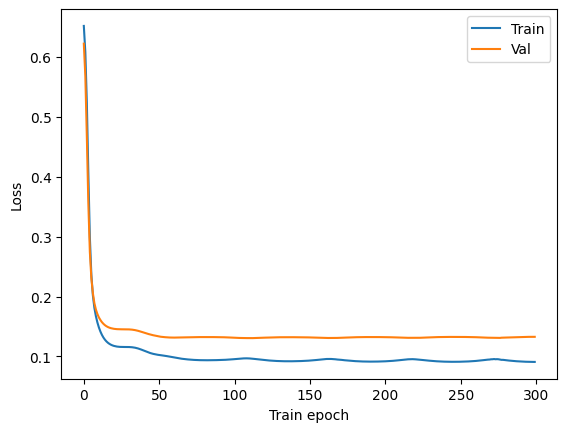

In [0]:
plot_losses(losses)

In [0]:
nn_model.eval()
pred_y_test = np.argmax(nn_model(test_data[0].to(device)).cpu().detach(), axis=1)

influence_model = DirectInfluence(
    nn_model,
    F.cross_entropy,
    regularization=0.1,
)
influence_model = influence_model.fit(training_data_loader)
train_influences = influence_model.influences(*test_data, *training_data, mode="up")

mean_train_influences = np.mean(train_influences.cpu().numpy(), axis=0)

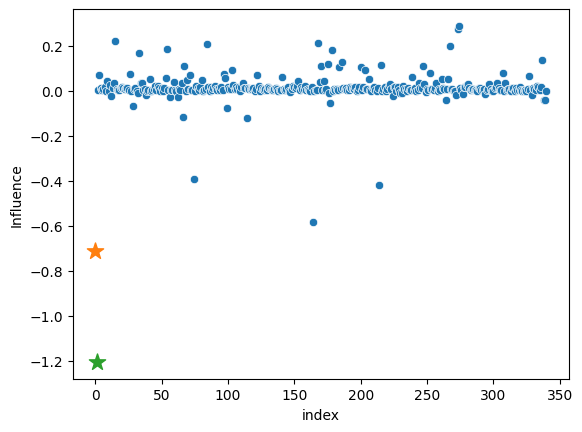

In [0]:
sns.scatterplot(x=pd.Series(range(len(mean_train_influences)), name='index'),y=pd.Series(mean_train_influences, name='Influence'))
plt.scatter(0, mean_train_influences[0], marker="*", s=150)
plt.scatter(1, mean_train_influences[1], marker="*", s=150) 

### IOM cancer

Calculate the SHAP values.

In [0]:
e = shap.DeepExplainer(nn_model, training_data[0].to(device))

In [0]:
shap_values = e.shap_values(training_data[0].to(device))[:, : , 0]

Calculate the deviance residuals.

In [0]:
nn_model.eval()
y_test = training_data[1].numpy() 
y_prob = F.softmax(nn_model(training_data[0].to(device))).cpu().detach().numpy()[:,1]

/root/.ipykernel/87580/command-5365087733801638-1914852608:3: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  y_prob = F.softmax(nn_model(training_data[0].to(device))).cpu().detach().numpy()[:,1]


In [0]:
eps = 1e-15  # to avoid log(0)
y_prob = np.clip(y_prob, eps, 1 - eps)
resid = np.sign(y_test - y_prob) * np.sqrt(-2 * (y_test * np.log(y_prob) + (1 - y_test) * np.log(1 - y_prob)))

Test the normality of the SHAP values and the residuals.

In [0]:
print("SHAP values:", multivariate_normality(shap_values).pval), 
print("Residuals:", stats.shapiro(resid.reshape(-1)).pvalue)

SHAP values: 0.0
Residuals: 9.085596255462168e-20


Define the normalizing flows function.

In [0]:
iom = InfluentialOutlierMetric(shap_values, resid,
                               16, 4, 16, 
                               6, 2, 6, 
                               lambdas=np.concatenate([[0], np.exp(np.linspace(-6, 5, 50))]),
                               lambdas_resid=np.concatenate([[0], np.exp(np.linspace(-5, 10, 50))]),
                               epoch=1000, epoch_resid=500)

Tune \\(\lambda\\).

In [0]:
# Tune for lambda
iom.find_best_lambda(alpha=0.05)
iom.find_best_lambda_resid(alpha=0.05)

# Compute thresholds
thresholds = iom.find_threshold(alpha=[0.05, 0.01])

# Compute IOM
IOM_ = iom.IOM()

Finding lambda for SHAP values
Henze–Zirkler p-value = 0.0000
λ=0.0000


 49%|████▉     | 492/1000

*** WARNING: max output size exceeded, skipping output. ***

100%|██████████| 1000/1000 [13:42<00:00,  1.22it/s]


p=0.1270
λ=0.0067


 49%|████▉     | 492/1000

*** WARNING: max output size exceeded, skipping output. ***

100%|██████████| 1000/1000 [13:39<00:00,  1.22it/s]


p=0.0007
Selected λ=0.0000, p=0.1270
Done!
Finding lambda for residuals
Shapiro p-value = 0.0000
λ=0.0000


...

p=0.1279
λ=0.1059


100%|██████████| 500/500 [02:21<00:00,  3.53it/s]


p=0.0566
λ=0.1439


100%|██████████| 500/500 [02:20<00:00,  3.55it/s]

p=0.0165
Selected λ=0.1059, p=0.0566
Done!
Threshold at 0.05: 116.9216
Threshold at 0.01: 210.6405


Plot the IOM vs. the training index.

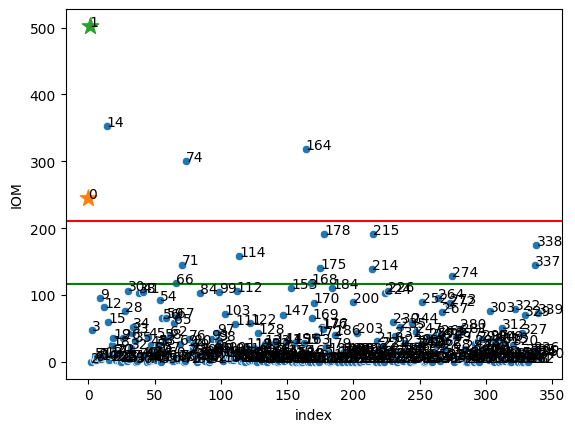

In [0]:
sns.scatterplot(x=pd.Series(range(len(IOM_)), name='index') ,y=IOM_)
plt.scatter(0, IOM_[0], marker="*", s=150)
plt.scatter(1, IOM_[1], marker="*", s=150)
plt.axhline(y=116.9216, color='green')
plt.axhline(y=210.6405, color='red')
for i, txt in enumerate(range(len(IOM_))):
    plt.annotate(txt, (i, IOM_[i]))

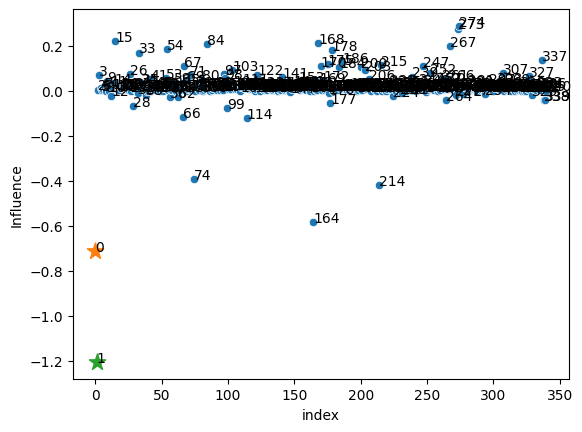

In [0]:
sns.scatterplot(x=pd.Series(range(len(mean_train_influences)), name='index'),y=pd.Series(mean_train_influences, name='Influence'))
plt.scatter(0, mean_train_influences[0], marker="*", s=150)
plt.scatter(1, mean_train_influences[1], marker="*", s=150) 
for i, txt in enumerate(range(len(mean_train_influences))):
    plt.annotate(txt, (i, mean_train_influences[i]))